In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import sys
sys.path.append('/content/drive/MyDrive/github/cls-vs-mean-pooling-transformer-classification/src/py')

# Config

In [3]:
import torch
import json

config_path = '/content/drive/MyDrive/github/cls-vs-mean-pooling-transformer-classification/src/py/configs/config_dropout_0.3_n_layer=12.json'
with open(config_path, 'r') as f:
    config = json.load(f)

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# 1. path
train_csv_path = config['paths']['train_csv']
val_csv_path = config['paths']['val_csv']
test_csv_path = config['paths']['test_csv']
model_path = config['paths']['model_path']

# 2. Hyper parameter
max_len = config['model']['max_len']
vocab_size = config['model']['vocab_size']
n_head = config['model']['n_head']
d_ff = config['model']['d_ff']
n_layers = config['model']['n_layers']
num_class = config['model']['num_class']
dropout = config['model']['dropout']

# 3. Batch size
train_batch_size = config['train']['train_batch_size']
val_batch_size = config['train']['val_batch_size']
test_batch_size = config['train']['test_batch_size']

# Dataset / DataLoader

In [4]:
from dataset import AGNewsDataset
from dataset import collate_fn
from torch.utils.data import DataLoader

# train
train_dataset = AGNewsDataset(train_csv_path, model_path, max_len)
train_loader = DataLoader(train_dataset, batch_size = train_batch_size, shuffle=True, collate_fn=collate_fn)

# val
val_dataset = AGNewsDataset(val_csv_path, model_path, max_len)
val_loader = DataLoader(val_dataset, batch_size = val_batch_size, shuffle=False, collate_fn=collate_fn)

# test
test_dataset = AGNewsDataset(test_csv_path, model_path, max_len)
test_loader = DataLoader(test_dataset, batch_size = test_batch_size, shuffle=False, collate_fn=collate_fn)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Model

In [7]:
from model import TransformerClassifier

mean_pooling_model = TransformerClassifier(vocab_size=vocab_size,
                                       max_len=max_len,
                                       d_model=256,
                                       n_head=n_head,
                                       d_ff=d_ff,
                                       n_layers=n_layers,
                                       num_class=num_class,
                                       dropout=dropout).to(device)

cls_model = TransformerClassifier(vocab_size=vocab_size,
                                       max_len=max_len,
                                       d_model=256,
                                       n_head=n_head,
                                       d_ff=d_ff,
                                       n_layers=n_layers,
                                       num_class=num_class,
                                       dropout=dropout).to(device)

# Train

In [ ]:
from sklearn.metrics import accuracy_score
from torch import nn
from torch import optim

criterion = nn.CrossEntropyLoss()
m_optimizer = torch.optim.Adam(mean_pooling_model.parameters(), lr=0.0001)
c_optimizer = torch.optim.Adam(cls_model.parameters(), lr=0.0001)

tr_mean_losses, tr_cls_losses = [], []
tr_mean_accs, tr_cls_accs = [], []

val_mean_losses, val_cls_losses = [], []
val_mean_accs, val_cls_accs = [], []


for epoch in range(10):
    # train
    mean_pooling_model.train()
    cls_model.train()
    m_loss_tmp, c_loss_tmp = 0, 0
    m_tr_preds, c_tr_preds, tr_true_labels = [], [], []

    for token_ids, label, attention_mask in train_loader:
        token_ids, label, attention_mask = token_ids.to(device), label.to(device), attention_mask.to(device)

        # mean_pooling_model
        m_optimizer.zero_grad()
        m_output = mean_pooling_model(token_ids, attention_mask, is_mean_pooling=True)
        m_loss = criterion(m_output, label)
        m_loss.backward()
        m_optimizer.step()
        m_loss_tmp += m_loss.item()
        m_tr_preds.extend(torch.argmax(m_output, dim=1).cpu().numpy())

        # cls_model
        c_optimizer.zero_grad()
        c_output = cls_model(token_ids, attention_mask, is_mean_pooling=False)
        c_loss = criterion(c_output, label)
        c_loss.backward()
        c_optimizer.step()
        c_loss_tmp += c_loss.item()
        c_tr_preds.extend(torch.argmax(c_output, dim=1).cpu().numpy())

        tr_true_labels.extend(label.cpu().numpy())

    # tr_loss, tr_acc
    tr_mean_losses.append(m_loss_tmp / len(train_loader))
    tr_cls_losses.append(c_loss_tmp / len(train_loader))
    tr_mean_accs.append(accuracy_score(tr_true_labels, m_tr_preds))
    tr_cls_accs.append(accuracy_score(tr_true_labels, c_tr_preds))

    # validation
    mean_pooling_model.eval()
    cls_model.eval()
    m_val_loss, c_val_loss = 0, 0
    m_preds, c_preds, true_labels = [], [], []

    with torch.no_grad():
        for token_ids, label, attention_mask in val_loader:
            token_ids, label, attention_mask = token_ids.to(device), label.to(device), attention_mask.to(device)

            m_out = mean_pooling_model(token_ids, attention_mask, is_mean_pooling=True)
            c_out = cls_model(token_ids, attention_mask, is_mean_pooling=False)

            m_val_loss += criterion(m_out, label).item()
            c_val_loss += criterion(c_out, label).item()

            m_preds.extend(torch.argmax(m_out, dim=1).cpu().numpy())
            c_preds.extend(torch.argmax(c_out, dim=1).cpu().numpy())
            true_labels.extend(label.cpu().numpy())

    # val_loss, val_acc
    val_mean_losses.append(m_val_loss / len(val_loader))
    val_cls_losses.append(c_val_loss / len(val_loader))
    val_mean_accs.append(accuracy_score(true_labels, m_preds))
    val_cls_accs.append(accuracy_score(true_labels, c_preds))

    print(f"Epoch {epoch+1}")

Epoch 1
Epoch 2
Epoch 3
Epoch 4
Epoch 5
Epoch 6
Epoch 7
Epoch 8
Epoch 9
Epoch 10


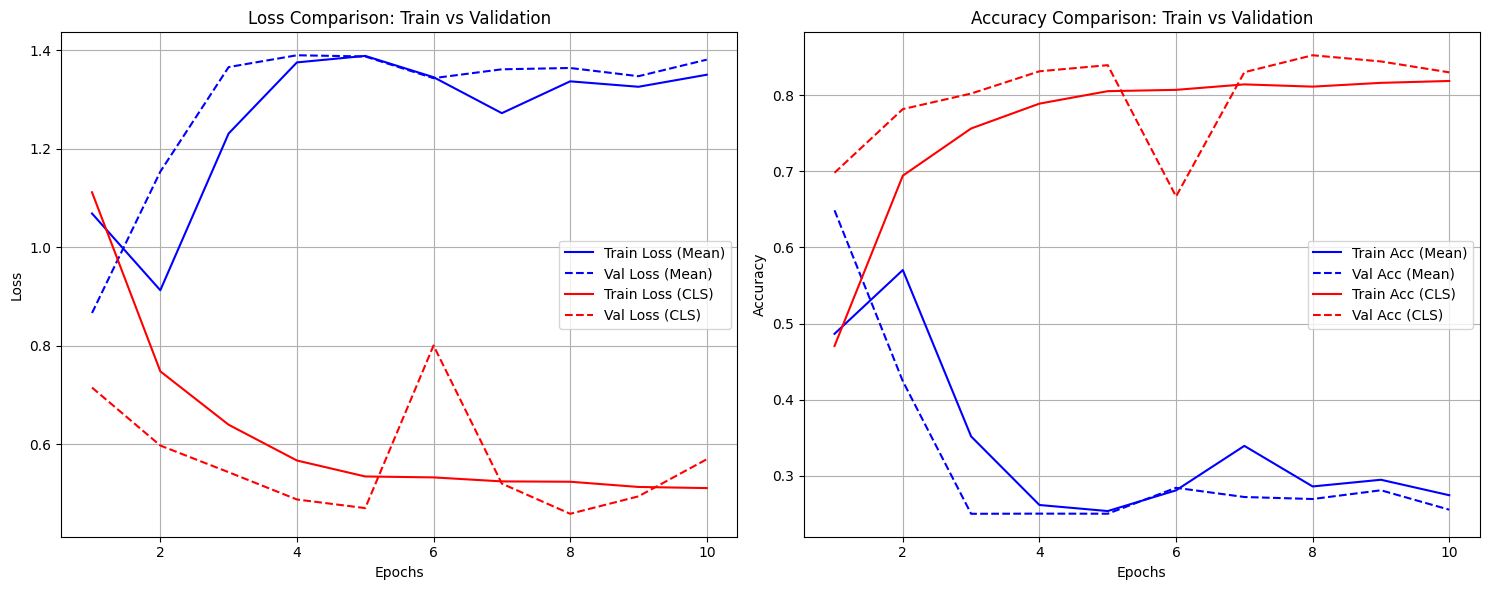

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(tr_mean_losses) + 1)

plt.figure(figsize=(15, 6))

# 1. Loss graph
plt.subplot(1, 2, 1)
plt.plot(epochs, tr_mean_losses, 'b', label='Train Loss (Mean)')
plt.plot(epochs, val_mean_losses, 'b--', label='Val Loss (Mean)')
plt.plot(epochs, tr_cls_losses, 'r', label='Train Loss (CLS)')
plt.plot(epochs, val_cls_losses, 'r--', label='Val Loss (CLS)')
plt.title('Loss Comparison: Train vs Validation')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# 2. Accuracy graph
plt.subplot(1, 2, 2)
plt.plot(epochs, tr_mean_accs, 'b', label='Train Acc (Mean)')
plt.plot(epochs, val_mean_accs, 'b--', label='Val Acc (Mean)')
plt.plot(epochs, tr_cls_accs, 'r', label='Train Acc (CLS)')
plt.plot(epochs, val_cls_accs, 'r--', label='Val Acc (CLS)')
plt.title('Accuracy Comparison: Train vs Validation')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# 저장 경로 설정
mean_model_path = '/content/drive/MyDrive/github/cls-vs-mean-pooling-transformer-classification/saved_models/mean_pooling_model_dropout_03_n_layer=12.pt'
cls_model_path = '/content/drive/MyDrive/github/cls-vs-mean-pooling-transformer-classification/saved_models/cls_model_dropout_03_n_layer=12.pt'

# 가중치 저장 (state_dict)
torch.save(mean_pooling_model.state_dict(), mean_model_path)
torch.save(cls_model.state_dict(), cls_model_path)

# Scoring with Validation dataset

In [6]:
from sklearn.metrics import accuracy_score, classification_report

def evaluation(true, preds, model_name="Model"):
    acc = accuracy_score(true, preds)
    report = classification_report(true, preds)

    print(f"========== [Evaluation] ==========")
    print(f"Accuracy: {acc:.4f}")
    print("\nClassification Report:")
    print(report)
    print("================================================\n")

base model

In [8]:
config_path = '/content/drive/MyDrive/github/cls-vs-mean-pooling-transformer-classification/src/py/configs/config_base.json'
with open(config_path, 'r') as f:
  config = json.load(f)

max_len = config['model']['max_len']
vocab_size = config['model']['vocab_size']
n_head = config['model']['n_head']
d_ff = config['model']['d_ff']
n_layers = config['model']['n_layers']
num_class = config['model']['num_class']
dropout = config['model']['dropout']

mean_pooling_model = TransformerClassifier(vocab_size=vocab_size,
                                       max_len=max_len,
                                       d_model=256,
                                       n_head=n_head,
                                       d_ff=d_ff,
                                       n_layers=n_layers,
                                       num_class=num_class,
                                       dropout=dropout).to(device)

cls_model = TransformerClassifier(vocab_size=vocab_size,
                                       max_len=max_len,
                                       d_model=256,
                                       n_head=n_head,
                                       d_ff=d_ff,
                                       n_layers=n_layers,
                                       num_class=num_class,
                                       dropout=dropout).to(device)

m_pt_path = '/content/drive/MyDrive/github/cls-vs-mean-pooling-transformer-classification/saved_models/base_mean_pooling_model.pt'
c_pt_path = '/content/drive/MyDrive/github/cls-vs-mean-pooling-transformer-classification/saved_models/base_cls_model.pt'

m_weights = torch.load(m_pt_path, map_location=device)
c_weights = torch.load(c_pt_path, map_location=device)

mean_pooling_model.load_state_dict(m_weights)
cls_model.load_state_dict(c_weights)

#eval
mean_pooling_model.eval()
cls_model.eval()

true = []
m_preds = []
c_preds = []

with torch.no_grad():
  for token_ids, label, attention_mask in val_loader:
    token_ids, label, attention_mask = token_ids.to(device), label.to(device), attention_mask.to(device)
    m_out = mean_pooling_model(token_ids, attention_mask, is_mean_pooling=True)
    c_out = cls_model(token_ids, attention_mask, is_mean_pooling=False)

    m_preds.extend(torch.argmax(m_out, dim=1).cpu().numpy().tolist())
    c_preds.extend(torch.argmax(c_out, dim=1).cpu().numpy().tolist())
    true.extend(label.cpu().numpy().tolist())

print('mean_pooling_model')
evaluation(true, m_preds)

print('cls_model')
evaluation(true, c_preds)

mean_pooling_model
========== [Evaluation] ==========
Accuracy: 0.9031

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.92      0.91      2458
           1       0.96      0.97      0.96      2457
           2       0.88      0.84      0.86      2458
           3       0.87      0.88      0.88      2458

    accuracy                           0.90      9831
   macro avg       0.90      0.90      0.90      9831
weighted avg       0.90      0.90      0.90      9831


cls_model
========== [Evaluation] ==========
Accuracy: 0.9018

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.91      0.91      2458
           1       0.96      0.97      0.97      2457
           2       0.86      0.87      0.86      2458
           3       0.88      0.85      0.87      2458

    accuracy                           0.90      9831
   macro avg       0.90      0.90      0.90      9831
wei

dropout=0.3 model

In [9]:
config_path = '/content/drive/MyDrive/github/cls-vs-mean-pooling-transformer-classification/src/py/configs/config_dropout_0.3.json'
with open(config_path, 'r') as f:
  config = json.load(f)

max_len = config['model']['max_len']
vocab_size = config['model']['vocab_size']
n_head = config['model']['n_head']
d_ff = config['model']['d_ff']
n_layers = config['model']['n_layers']
num_class = config['model']['num_class']
dropout = config['model']['dropout']

mean_pooling_model = TransformerClassifier(vocab_size=vocab_size,
                                       max_len=max_len,
                                       d_model=256,
                                       n_head=n_head,
                                       d_ff=d_ff,
                                       n_layers=n_layers,
                                       num_class=num_class,
                                       dropout=dropout).to(device)

cls_model = TransformerClassifier(vocab_size=vocab_size,
                                       max_len=max_len,
                                       d_model=256,
                                       n_head=n_head,
                                       d_ff=d_ff,
                                       n_layers=n_layers,
                                       num_class=num_class,
                                       dropout=dropout).to(device)

m_pt_path = '/content/drive/MyDrive/github/cls-vs-mean-pooling-transformer-classification/saved_models/mean_pooling_model_dropout_03.pt'
c_pt_path = '/content/drive/MyDrive/github/cls-vs-mean-pooling-transformer-classification/saved_models/cls_model_dropout_03.pt'

m_weights = torch.load(m_pt_path, map_location=device)
c_weights = torch.load(c_pt_path, map_location=device)

mean_pooling_model.load_state_dict(m_weights)
cls_model.load_state_dict(c_weights)

#eval
mean_pooling_model.eval()
cls_model.eval()

true = []
m_preds = []
c_preds = []

with torch.no_grad():
  for token_ids, label, attention_mask in val_loader:
    token_ids, label, attention_mask = token_ids.to(device), label.to(device), attention_mask.to(device)
    m_out = mean_pooling_model(token_ids, attention_mask, is_mean_pooling=True)
    c_out = cls_model(token_ids, attention_mask, is_mean_pooling=False)

    m_preds.extend(torch.argmax(m_out, dim=1).cpu().numpy().tolist())
    c_preds.extend(torch.argmax(c_out, dim=1).cpu().numpy().tolist())
    true.extend(label.cpu().numpy().tolist())

print('mean_pooling_model')
evaluation(true, m_preds)

print('cls_model')
evaluation(true, c_preds)

mean_pooling_model
========== [Evaluation] ==========
Accuracy: 0.8906

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.92      0.89      2458
           1       0.97      0.95      0.96      2457
           2       0.82      0.90      0.86      2458
           3       0.92      0.79      0.85      2458

    accuracy                           0.89      9831
   macro avg       0.89      0.89      0.89      9831
weighted avg       0.89      0.89      0.89      9831


cls_model
========== [Evaluation] ==========
Accuracy: 0.8982

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.91      0.91      2458
           1       0.94      0.98      0.96      2457
           2       0.86      0.87      0.87      2458
           3       0.89      0.83      0.86      2458

    accuracy                           0.90      9831
   macro avg       0.90      0.90      0.90      9831
wei

dropout=0.3, n_layer=12 model

In [10]:
config_path = '/content/drive/MyDrive/github/cls-vs-mean-pooling-transformer-classification/src/py/configs/config_dropout_0.3_n_layer=12.json'
with open(config_path, 'r') as f:
  config = json.load(f)

max_len = config['model']['max_len']
vocab_size = config['model']['vocab_size']
n_head = config['model']['n_head']
d_ff = config['model']['d_ff']
n_layers = config['model']['n_layers']
num_class = config['model']['num_class']
dropout = config['model']['dropout']

mean_pooling_model = TransformerClassifier(vocab_size=vocab_size,
                                       max_len=max_len,
                                       d_model=256,
                                       n_head=n_head,
                                       d_ff=d_ff,
                                       n_layers=n_layers,
                                       num_class=num_class,
                                       dropout=dropout).to(device)

cls_model = TransformerClassifier(vocab_size=vocab_size,
                                       max_len=max_len,
                                       d_model=256,
                                       n_head=n_head,
                                       d_ff=d_ff,
                                       n_layers=n_layers,
                                       num_class=num_class,
                                       dropout=dropout).to(device)

m_pt_path = '/content/drive/MyDrive/github/cls-vs-mean-pooling-transformer-classification/saved_models/mean_pooling_model_dropout_03_n_layer=12.pt'
c_pt_path = '/content/drive/MyDrive/github/cls-vs-mean-pooling-transformer-classification/saved_models/cls_model_dropout_03_n_layer=12.pt'

m_weights = torch.load(m_pt_path, map_location=device)
c_weights = torch.load(c_pt_path, map_location=device)

mean_pooling_model.load_state_dict(m_weights)
cls_model.load_state_dict(c_weights)

#eval
mean_pooling_model.eval()
cls_model.eval()

true = []
m_preds = []
c_preds = []

with torch.no_grad():
  for token_ids, label, attention_mask in val_loader:
    token_ids, label, attention_mask = token_ids.to(device), label.to(device), attention_mask.to(device)
    m_out = mean_pooling_model(token_ids, attention_mask, is_mean_pooling=True)
    c_out = cls_model(token_ids, attention_mask, is_mean_pooling=False)

    m_preds.extend(torch.argmax(m_out, dim=1).cpu().numpy().tolist())
    c_preds.extend(torch.argmax(c_out, dim=1).cpu().numpy().tolist())
    true.extend(label.cpu().numpy().tolist())

print('mean_pooling_model')
evaluation(true, m_preds)

print('cls_model')
evaluation(true, c_preds)

mean_pooling_model
========== [Evaluation] ==========
Accuracy: 0.2552

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      2458
           1       0.25      1.00      0.40      2457
           2       0.00      0.00      0.00      2458
           3       0.57      0.02      0.04      2458

    accuracy                           0.26      9831
   macro avg       0.20      0.26      0.11      9831
weighted avg       0.20      0.26      0.11      9831


cls_model
========== [Evaluation] ==========
Accuracy: 0.8302

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.77      0.83      2458
           1       0.81      0.97      0.88      2457
           2       0.79      0.78      0.79      2458
           3       0.83      0.80      0.82      2458

    accuracy                           0.83      9831
   macro avg       0.83      0.83      0.83      9831
wei

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
